# Monitoring ice velocity on Vega Island, Antarctica, using Sentinel-1 offset tracking

## Author: Moritz Rath

Geoprocessing with Python, Wintersemester 25/26, Geographisches Institut, Humboldt-Universität zu Berlin
Supervisors: Dr. Dirk Pflugmacher, Eduardo Ribeiro Lacerda

Hand-in due: March 15, 2026

**1. Import Packages**

In [19]:
import os
import ee
import geemap
import json
import geopandas as gpd
from arosics import COREG_LOCAL
import tempfile
from pathlib import Path

try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

path = 'C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data'

Import region shapefile for Vega Island

In [20]:
regionSHP = gpd.read_file(os.path.join(path, 'geodata/vega_island_outline.shp'))
regionSHP = regionSHP.to_crs(epsg=4326)
regionSHP = regionSHP.drop(columns=['sourcedate', 'revdate'])
regionJS = json.loads(regionSHP.to_json())
region = ee.FeatureCollection(regionJS)

In [3]:
Map = geemap.Map()
Map.centerObject(region, 10)
Map.addLayer(region, {}, 'Region')
Map

Map(center=[-63.848051711623604, -57.38302088676081], controls=(WidgetControl(options=['position', 'transparen…

Get data from GEE

In [21]:
s1 = (ee.ImageCollection('COPERNICUS/S1_GRD')
      .filterBounds(region)
      .filterDate('2024-01-01', '2025-01-01')
      .filter(ee.Filter.eq('instrumentMode', 'IW'))
      .select('HH'))
s1

**Coregister consecutive image pairs**

In [32]:
regionEXP = ee.FeatureCollection(region).geometry()
regionEXP = regionEXP.transform('EPSG:4326', maxError=1)

In [ ]:
collection_list = s1.toList(s1.size())
n_images = s1.size().getInfo()
print(f"Total images in collection: {n_images}")

Total images in collection: 31


In [ ]:
img1 = ee.Image(collection_list.get(0))
img2 = ee.Image(collection_list.get(1))

In [ ]:
temp_dir = tempfile.mkdtemp()
temp_img1_path = os.path.join(temp_dir, 'img1_consecutive.tif')
temp_img2_path = os.path.join(temp_dir, 'img2_consecutive.tif')
print(f"Exporting images to temporary directory: {temp_dir}")

Exporting images to temporary directory: C:\Users\morit\AppData\Local\Temp\tmp9wnej76f


In [ ]:
geemap.ee_export_image(img1, filename=temp_img1_path, scale=10, 
                       region=regionEXP, file_per_band=False)
geemap.ee_export_image(img2, filename=temp_img2_path, scale=10, 
                       region=regionEXP, file_per_band=False)

print(f"Image 1 exported to: {temp_img1_path}")
print(f"Image 2 exported to: {temp_img2_path}")

Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp9wnej76f\img1_consecutive.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp9wnej76f\img2_consecutive.tif
Image 1 exported to: C:\Users\morit\AppData\Local\Temp\tmp9wnej76f\img1_consecutive.tif
Image 2 exported to: C:\Users\morit\AppData\Local\Temp\tmp9wnej76f\img2_consecutive.tif


In [37]:
kwargs = {
    'grid_res': 200,
    'window_size': (256, 256),
    'path_out': 'auto',
    'projectDir': '',
    'q' : False,
}

In [ ]:
print("\nProcessing with COREG_LOCAL...")
coreg = COREG_LOCAL(temp_img2_path, temp_img1_path,**kwargs)
coreg.correct_shifts()


Processing with COREG_LOCAL...
Calculating footprint polygon and actual data corner coordinates for reference image...
Bounding box of calculated footprint for reference image:
	(465237.0454664328, 2910357.061634654, 497437.0454664328, 2926867.061634654)
Calculating footprint polygon and actual data corner coordinates for image to be shifted...
Bounding box of calculated footprint for image to be shifted:
	(465237.2776985968, 2910363.3971180413, 497437.2776985968, 2926863.3971180413)
Matching window position (X,Y): 481337.1615825148/2918613.3971180413
Initializing tie points grid...


Warping progress     |--------------------------------------------------| 1.0% Complete  => 0:00:00

Equalizing pixel grids and projections of reference and target image...


Warping progress     |==================================================| 100.0% Complete  => 0:00:00
Warping progress     |==================================================| 100.0% Complete  => 0:00:00


Calculating tie point grid (153 points) using 8 CPU cores...


	progress: |==================================================| 100.0% Complete  => 0:00:13


Found 79 matches.
Performing validity checks...
31 tie points flagged by level 1 filtering (reliability).
53 tie points flagged by level 2 filtering (SSIM).
0 tie points flagged by level 3 filtering (RANSAC)
14 valid tie points remain after filtering.
Correcting geometric shifts...


Translating progress |==================================================| 100.0% Complete  => 0:00:00
Warping progress     |==================================================| 100.0% Complete  => 0:00:00


Writing GeoArray of size (1649, 3219) to C:\Users\morit\AppData\Local\Temp\tmp9wnej76f\img1_consecutive__shifted_to__img2_consecutive.bsq.


{'band': None,
 'is shifted': True,
 'is resampled': True,
 'updated map info': ['UTM',
  1.0,
  1.0,
  465247.0454664328,
  2926857.061634654,
  10.0,
  10.0,
  21,
  'South',
  'WGS-84'],
 'updated geotransform': (465247.0454664328,
  10.0,
  0.0,
  2926857.061634654,
  0.0,
  -10.0),
 'updated projection': 'PROJCS["WGS 84 / UTM zone 21S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-57],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32721"]]',
 'arr_shifted': array([[-25.35579148, -31.45803816, -29.03665994, ..., -28.83467

Note: array has been downsampled to 999 x 512 for faster visualization.


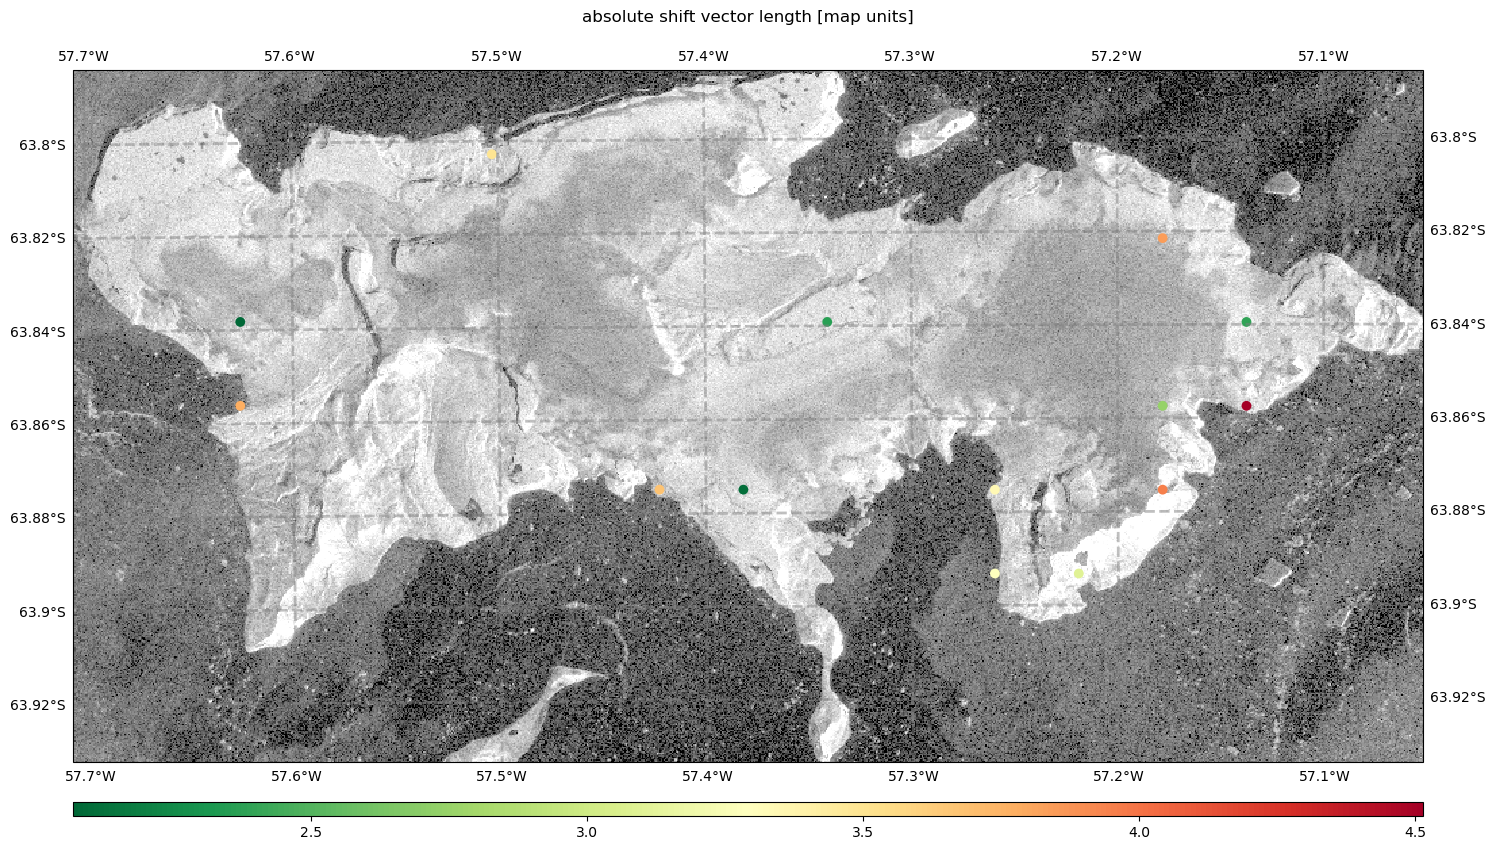

In [41]:
coreg.view_CoRegPoints(figsize=(15,15), backgroundIm='ref')

Calculating footprint polygon and actual data corner coordinates for reference image...
Bounding box of calculated footprint for reference image:
	(465237.0454664328, 2910357.061634654, 497437.0454664328, 2926867.061634654)
Calculating footprint polygon and actual data corner coordinates for image to be shifted...
Bounding box of calculated footprint for image to be shifted:
	(465247.045466433, 2910367.06163465, 497437.045466433, 2926857.06163465)
Matching window position (X,Y): 481342.04546643293/2918612.06163465
Note: array has been downsampled to 999 x 512 for faster visualization.
Initializing tie points grid...
Calculating tie point grid (153 points) using 8 CPU cores...


	progress: |==================================================| 100.0% Complete  => 0:00:05


Found 86 matches.
Performing validity checks...
38 tie points flagged by level 1 filtering (reliability).
26 tie points flagged by level 2 filtering (SSIM).
1 tie points flagged by level 3 filtering (RANSAC)
31 valid tie points remain after filtering.


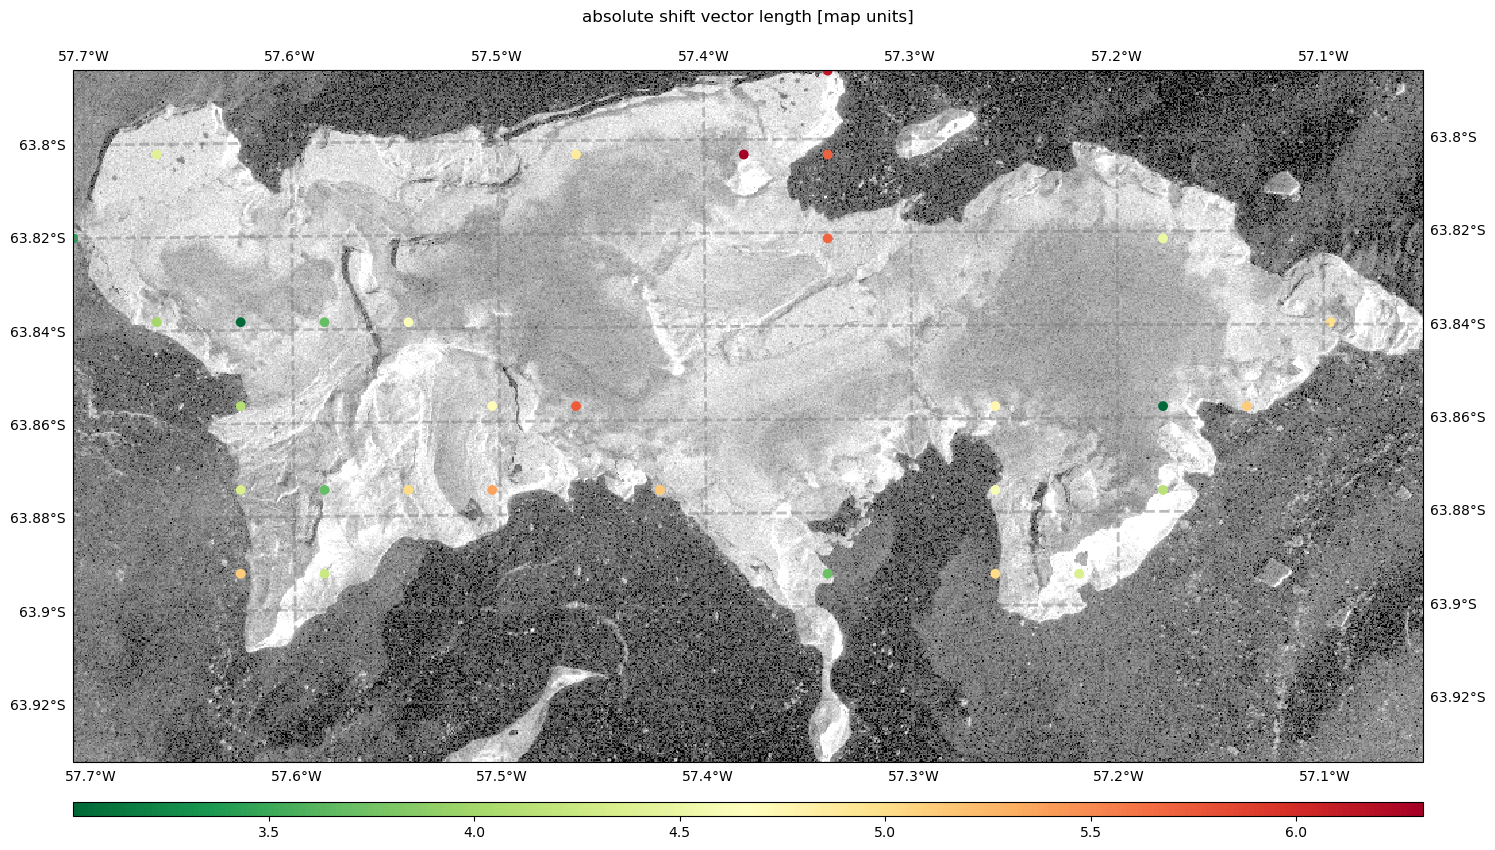

In [42]:
crl_afterCORR = COREG_LOCAL(temp_img2_path, coreg.path_out, **kwargs)
crl_afterCORR.view_CoRegPoints(figsize=(15,15),backgroundIm='ref')

In [43]:
coreg.CoRegPoints_table

,geometry,POINT_ID,X_IM,Y_IM,X_MAP,Y_MAP,REF_BADDATA,TGT_BADDATA,X_WIN_SIZE,Y_WIN_SIZE,...,SSIM_BEFORE,SSIM_AFTER,SSIM_IMPROVED,RELIABILITY,LAST_ERR,WARNINGS,L1_OUTLIER,L2_OUTLIER,L3_OUTLIER,OUTLIER
0,POINT (465237.278 2926863.397),0,0,0,465237.277699,2.926863e+06,False,False,-9999.0,-9999.0,...,-9999.0,-9999.0,-9999,-9999.0,The provided window position (np.float64(46523...,[],-9999,-9999,-9999,-9999
1,POINT (467237.278 2926863.397),1,200,0,467237.277699,2.926863e+06,False,False,-9999.0,-9999.0,...,-9999.0,-9999.0,-9999,-9999.0,Matching window in target image is larger than...,[],-9999,-9999,-9999,-9999
2,POINT (469237.278 2926863.397),2,400,0,469237.277699,2.926863e+06,False,False,-9999.0,-9999.0,...,-9999.0,-9999.0,-9999,-9999.0,Matching window in target image is larger than...,[],-9999,-9999,-9999,-9999
3,POINT (471237.278 2926863.397),3,600,0,471237.277699,2.926863e+06,False,False,-9999.0,-9999.0,...,-9999.0,-9999.0,-9999,-9999.0,Matching window in target image is larger than...,[],-9999,-9999,-9999,-9999
4,POINT (473237.278 2926863.397),4,800,0,473237.277699,2.926863e+06,False,False,-9999.0,-9999.0,...,-9999.0,-9999.0,-9999,-9999.0,Matching window in target image is larger than...,[],-9999,-9999,-9999,-9999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,POINT (489237.278 2910863.397),156,2400,1600,489237.277699,2.910863e+06,False,False,256.0,178.0,...,-9999.0,-9999.0,-9999,-9999.0,No match found in the given window.,[],-9999,-9999,-9999,-9999
149,POINT (491237.278 2910863.397),157,2600,1600,491237.277699,2.910863e+06,False,False,256.0,178.0,...,-9999.0,-9999.0,-9999,-9999.0,No match found in the given window.,[],-9999,-9999,-9999,-9999
150,POINT (493237.278 2910863.397),158,2800,1600,493237.277699,2.910863e+06,False,False,256.0,178.0,...,-9999.0,-9999.0,-9999,-9999.0,No match found in the given window.,[],-9999,-9999,-9999,-9999
151,POINT (495237.278 2910863.397),159,3000,1600,495237.277699,2.910863e+06,False,False,256.0,178.0,...,-9999.0,-9999.0,-9999,-9999.0,No match found in the given window.,[],-9999,-9999,-9999,-9999
